In [ ]:
!pip install -q -U trl transformers peft accelerate bitsandbytes datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 520.7/520.7 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 48.0 MB/s eta 0:00:00


In [ ]:
!pip install -U bitsandbytes>=0.46.1 accelerate transformers tiktoken sentencepiece

In [ ]:
!pip install -U bitsandbytes>=0.46.1 accelerate transformers

In [ ]:
# 1. تثبيت المكتبات المطلوبة
!pip uninstall -y pyarrow datasets # Uninstall pyarrow and datasets to resolve potential version conflicts
!pip install -q -U pyarrow datasets transformers peft accelerate bitsandbytes scikit-learn seaborn matplotlib

import os
import pandas as pd
from datasets import Dataset
from google.colab import drive
import shutil # Import shutil for rmtree

# 2. ربط Google Drive (مهم جداً)
# Ensure /content/drive is clean before mounting
if os.path.exists('/content/drive'):
    try:
        # Attempt to unmount if it's already mounted
        drive.flush_and_unmount()
        print("Google Drive unmounted successfully.")
    except ValueError:
        # If not mounted, it will raise ValueError. In this case, check and clear the directory.
        pass # Drive was not mounted, proceed to check directory content

    # After unmount attempt (or if not mounted), check if the directory still contains files
    if os.path.isdir('/content/drive') and os.listdir('/content/drive'):
        print("Warning: /content/drive exists and is not empty. Attempting to clear it before mounting.")
        try:
            shutil.rmtree('/content/drive')
            os.makedirs('/content/drive')
            print("/content/drive cleared and recreated.")
        except Exception as e:
            print(f"Error clearing /content/drive: {e}")
    elif os.path.exists('/content/drive') and not os.path.isdir('/content/drive'):
        # If it exists but isn't a directory (e.g., a file), remove it and create a directory
        try:
            os.remove('/content/drive')
            os.makedirs('/content/drive')
            print("/content/drive (file) removed and directory created.")
        except Exception as e:
            print(f"Error removing /content/drive (file) and recreating directory: {e}")

drive.mount('/content/drive', force_remount=True)

# 3. قراءة البيانات الأصلية
df = pd.read_csv("/content/drive/MyDrive/Project/synthetic_sensitivity_dataset_v3.csv")

# 4. تحويلها وتقسيمها بنفس طريقة التدريب تماماً (لاستخراج test_data)
dataset = Dataset.from_pandas(df)
train_test_split = dataset.train_test_split(test_size=0.15, seed=42)
test_data = train_test_split['test'] # هذه هي البيانات التي لم يراها النموذج

# تحويلها إلى Pandas DataFrame لتسهيل التعامل في التقييم
test_data_df = test_data.to_pandas()
print(f"✅ تم تجهيز بيانات الاختبار بنجاح! العدد: {len(test_data_df)} وثيقة.")

Found existing installation: pyarrow 24.0.0
Uninstalling pyarrow-24.0.0:
  Successfully uninstalled pyarrow-24.0.0
Found existing installation: datasets 4.8.5
Uninstalling datasets-4.8.5:
  Successfully uninstalled datasets-4.8.5


ValueError: pyarrow.lib.IpcReadOptions size changed, may indicate binary incompatibility. Expected 112 from C header, got 104 from PyObject

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel
from huggingface_hub import login
from google.colab import userdata

# 1. تسجيل الدخول في Hugging Face (للوصول إلى Llama-3.1)
login(token=userdata.get('HF_TOKEN'))

model_id = "meta-llama/Meta-Llama-3.1-8B-Instruct"

# 2. إعدادات التكميم (نفس التي استخدمتها في التدريب)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

print("جاري تحميل Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left" # 👈 السر الذهبي لمنع هلوسة النموذج بالإنجليزية

print("جاري تحميل النموذج الأساسي...")
base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16
)

print("جاري تركيب الأوزان المدربة (NDMO LoRA)...")
# يمكنك تغيير 'checkpoint-400' إلى 'final_model' إذا أردت
saved_model_path = saved_model_path = "/content/drive/MyDrive/llama_ndmo_classifier/final_model"
model = PeftModel.from_pretrained(base_model, saved_model_path)
model.eval()

print("✅ النموذج جاهز للاختبار الآن!")

جاري تحميل Tokenizer...
جاري تحميل النموذج الأساسي...


`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

جاري تركيب الأوزان المدربة (NDMO LoRA)...
✅ النموذج جاهز للاختبار الآن!


/usr/local/lib/python3.12/dist-packages/peft/peft_model.py:598: UserWarning: Found missing adapter keys while loading the checkpoint: ['base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight', 'base_model.model.model.layers.0.self_attn.k_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.k_proj.lora_B.default.weight', 'base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight', 'base_model.model.model.layers.0.self_attn.o_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.o_proj.lora_B.default.weight', 'base_model.model.model.layers.0.mlp.gate_proj.lora_A.default.weight', 'base_model.model.model.layers.0.mlp.gate_proj.lora_B.default.weight', 'base_model.model.model.layers.0.mlp.up_proj.lora_A.default.weight', 'base_model.model.model.layers.0.mlp.up_proj.lora_B.default.we

🚀 بدء تقييم جديد. النتائج تُحفظ في الدرايف أولاً بأول.


جاري التصنيف: 100%|██████████| 375/375 [32:58<00:00,  5.27s/it]



              precision    recall  f1-score   support

         عام       0.24      0.06      0.10      1513
        مقيد       0.24      0.39      0.29      1476
         سري       0.23      0.11      0.15      1540
  سري للغاية       0.25      0.01      0.02      1471

   micro avg       0.24      0.14      0.18      6000
   macro avg       0.24      0.14      0.14      6000
weighted avg       0.24      0.14      0.14      6000



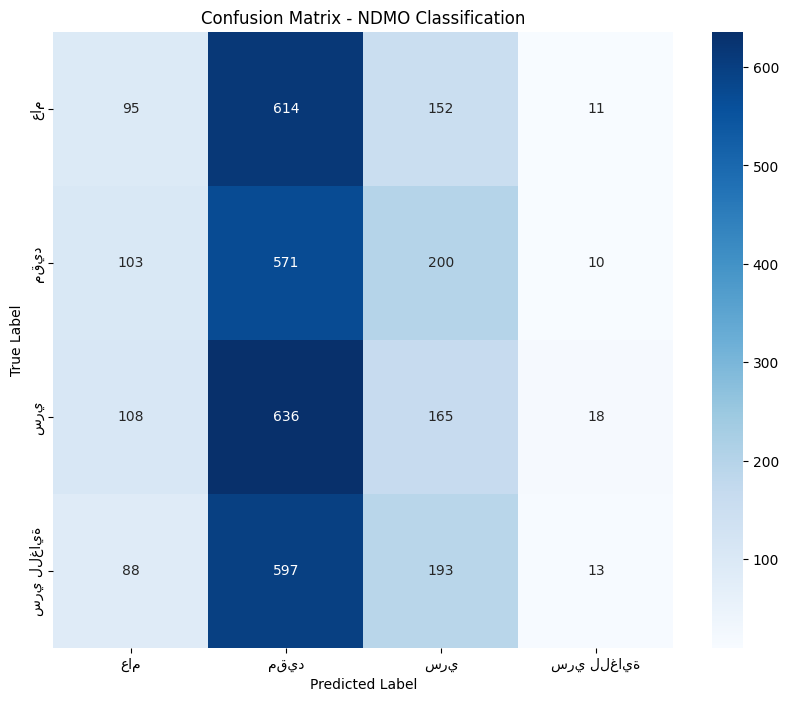

In [ ]:
import pandas as pd
import torch
import os
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. إعدادات المسارات والحفظ في الدرايف
# ==========================================
DRIVE_PATH = "/content/drive/MyDrive/llama_ndmo_classifier/"
if not os.path.exists(DRIVE_PATH):
    os.makedirs(DRIVE_PATH)

SAVE_FILE = DRIVE_PATH + "ndmo_predictions_prompt_test.csv"

BATCH_SIZE = 16
MAX_LENGTH = 512
torch.backends.cudnn.benchmark = True

# ==========================================
# 2. نظام الاستئناف (لمنع ضياع الوقت لو انقطع الاتصال)
# ==========================================
if os.path.exists(SAVE_FILE):
    saved_df = pd.read_csv(SAVE_FILE)
    processed_indices = set(saved_df['original_index'].tolist())
    print(f"♻️ تم العثور على {len(processed_indices)} وثيقة تم تقييمها سابقاً في الدرايف.")
else:
    processed_indices = set()
    pd.DataFrame(columns=['original_index', 'content', 'true_label', 'predicted_label']).to_csv(SAVE_FILE, index=False)
    print("🚀 بدء تقييم جديد. النتائج تُحفظ في الدرايف أولاً بأول.")

# استبعاد الوثائق التي تم تقييمها مسبقاً
remaining_data = test_data_df[~test_data_df.index.isin(processed_indices)]
indices = remaining_data.index.tolist()
texts = remaining_data['content'].tolist()
true_labels = remaining_data['sensitivity_level'].tolist()

# === القالب المطابق 100% لبيانات تدريبك ===
def get_prompt_exact(content):
    system_prompt = "أنت مساعد ذكي متخصص في تصنيف الوثائق الإدارية السعودية حسب معايير NDMO. صنف الوثيقة التالية إلى فئة واحدة فقط: (عام، مقيد، سري، سري للغاية)."
    user_prompt = f"الوثيقة: {content}"
    return f"System: {system_prompt}\nUser: {user_prompt}\nAssistant: "

# ==========================================
# 3. حلقة الاختبار والتصنيف
# ==========================================
if len(texts) > 0:
    with torch.inference_mode():
        for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="جاري التصنيف"):
            batch_texts = texts[i : i + BATCH_SIZE]
            batch_indices = indices[i : i + BATCH_SIZE]
            batch_true = true_labels[i : i + BATCH_SIZE]

            prompts = [get_prompt_exact(text) for text in batch_texts]
            inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True, max_length=MAX_LENGTH).to("cuda")

            with torch.autocast(device_type='cuda', dtype=torch.float16):
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=10,
                    temperature=0.01,
                    do_sample=False,
                    pad_token_id=tokenizer.pad_token_id,
                    use_cache=True
                )

            decoded_outputs = tokenizer.batch_decode(outputs, skip_special_tokens=True)
            batch_results = []

            for j, response in enumerate(decoded_outputs):
                # استخراج الكلمة التي تأتي بعد Assistant:
                gen_text = response.split("Assistant:")[-1].strip()
                batch_results.append({
                    'original_index': batch_indices[j],
                    'content': batch_texts[j],
                    'true_label': batch_true[j],
                    'predicted_label': gen_text
                })

            # حفظ النتائج فوراً في الدرايف
            pd.DataFrame(batch_results).to_csv(SAVE_FILE, mode='a', header=False, index=False)

            # تنظيف الذاكرة بعد كل دفعة
            del inputs, outputs, prompts
            torch.cuda.empty_cache()

# ==========================================
# 4. التقييم النهائي وعرض النتائج
# ==========================================
final_df = pd.read_csv(SAVE_FILE)
valid_classes = ["عام", "مقيد", "سري", "سري للغاية"]

def clean_prediction(pred_text):
    if not isinstance(pred_text, str): return "غير معروف"
    for cls in ["سري للغاية", "سري", "مقيد", "عام"]:
        if cls in pred_text: return cls
    return "غير معروف"

final_df['cleaned_pred'] = final_df['predicted_label'].apply(clean_prediction)

print("\n" + "="*50)
print(classification_report(final_df['true_label'], final_df['cleaned_pred'], labels=valid_classes))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(final_df['true_label'], final_df['cleaned_pred'], labels=valid_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=valid_classes, yticklabels=valid_classes)
plt.title('Confusion Matrix - NDMO Classification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
import pandas as pd
from datasets import Dataset

# قراءة البيانات
df = pd.read_csv("/content/drive/MyDrive/Project/synthetic_sensitivity_dataset_v3.csv")

# دالة القالب لتجهيز النصوص
def format_prompt(row):
    system_prompt = "أنت مساعد ذكي متخصص في تصنيف الوثائق الإدارية السعودية حسب معايير NDMO. صنف الوثيقة التالية إلى فئة واحدة فقط: (عام، مقيد، سري، سري للغاية)."
    user_prompt = f"الوثيقة: {row['content']}"
    assistant_response = row['sensitivity_level']
    return {"formatted_text": f"System: {system_prompt}\nUser: {user_prompt}\nAssistant: {assistant_response}"}

# تحويل وتقسيم البيانات (85% تدريب)
dataset = Dataset.from_pandas(df)
dataset = dataset.map(format_prompt)
train_test_split = dataset.train_test_split(test_size=0.15, seed=42)
train_data = train_test_split['train']

print(f"✅ تم تجهيز بيانات التدريب بنجاح! العدد الفعلي: {len(train_data)} وثيقة جاهزة.")

Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

✅ تم تجهيز بيانات التدريب بنجاح! العدد الفعلي: 34000 وثيقة جاهزة.


In [ ]:
import torch
import gc
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model
from trl import SFTTrainer, SFTConfig

# تنظيف ذاكرة الكرت
torch.cuda.empty_cache()
gc.collect()

model_id = "meta-llama/Meta-Llama-3.1-8B-Instruct"

# إعدادات التكميم
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

print("جاري تحميل النموذج والـ Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right" # ممتاز للتدريب

model = AutoModelForCausalLM.from_pretrained(
    model_id, quantization_config=bnb_config, device_map={"": 0}, torch_dtype=torch.float16
)
model.config.torch_dtype = torch.float16
model = prepare_model_for_kbit_training(model)

# إعدادات LoRA
peft_config = LoraConfig(
    r=16, lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05, bias="none", task_type="CAUSAL_LM",
)
model = get_peft_model(model, peft_config)

# تطهير الأوزان
for param in model.parameters():
    if param.dtype == torch.bfloat16:
        param.data = param.data.to(torch.float16)

# ==========================================
# إعدادات التدريب المحسنة (الحل الجذري)
# ==========================================
sft_config = SFTConfig(
    output_dir="/content/drive/MyDrive/llama_ndmo_classifier/full_training", # الحفظ في مجلد جديد
    dataset_text_field="formatted_text",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    optim="paged_adamw_32bit",
    learning_rate=2e-4,
    lr_scheduler_type="cosine",

    num_train_epochs=1,         # 👈 السماح للنموذج بقراءة كل البيانات بدلاً من التوقف المبكر!

    save_strategy="epoch",      # حفظ الأوزان عند نهاية الدورة
    logging_steps=50,
    max_grad_norm=0.3,
    warmup_ratio=0.03,
    fp16=False,
    bf16=False,
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_data,
    processing_class=tokenizer,
    args=sft_config,
)

print("\n🚀 انطلاق التدريب الشامل! النموذج سيقرأ جميع الوثائق الآن...")
trainer.train()

trainer.model.save_pretrained("/content/drive/MyDrive/llama_ndmo_classifier/full_training/final_model")
print("\n✅ اكتمل التدريب الشامل! الأوزان الذكية محفوظة الآن في الدرايف جاهزة للاختبار.")

جاري تحميل النموذج والـ Tokenizer...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.



🚀 انطلاق التدريب الشامل! النموذج سيقرأ جميع الوثائق الآن...


Step,Training Loss
50,1.651303
100,0.294722
150,0.235252
200,0.228878
250,0.222723
300,0.219171
350,0.215820
400,0.212980
450,0.212714
500,0.209929


Step,Training Loss
50,1.651303
100,0.294722
150,0.235252
200,0.228878
250,0.222723
300,0.219171
350,0.215820
400,0.212980
450,0.212714
500,0.209929



✅ اكتمل التدريب الشامل! الأوزان الذكية محفوظة الآن في الدرايف جاهزة للاختبار.


In [ ]:
#اختبار

## Zero-Shot

In [ ]:
# 1. تثبيت المكتبات
!pip install -q -U transformers peft accelerate bitsandbytes datasets scikit-learn seaborn matplotlib pyarrow

import os
import pandas as pd
from datasets import Dataset
from google.colab import drive, userdata
from huggingface_hub import login

# 2. ربط الدرايف وتسجيل الدخول
if not os.path.ismount('/content/drive'): drive.mount('/content/drive')
login(token=userdata.get('HF_TOKEN'))

# 3. قراءة وتقسيم البيانات (بنفس الطريقة لاستخراج عينة الاختبار الدقيقة)
df = pd.read_csv("/content/drive/MyDrive/Project/synthetic_sensitivity_dataset_v3.csv")
dataset = Dataset.from_pandas(df)
train_test_split = dataset.train_test_split(test_size=0.15, seed=42)
test_data_df = train_test_split['test'].to_pandas()

print(f"✅ تم تجهيز بيانات الاختبار! العدد: {len(test_data_df)} وثيقة عربية.")

✅ تم تجهيز بيانات الاختبار! العدد: 6000 وثيقة عربية.


In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

model_id = "meta-llama/Meta-Llama-3.1-8B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

print("جاري تحميل Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left" # الحشو الأيسر لمنع الهلوسة

print("جاري تحميل النموذج الأساسي...")
base_model = AutoModelForCausalLM.from_pretrained(
    model_id, quantization_config=bnb_config, device_map="auto", torch_dtype=torch.float16
)

print("جاري تركيب الأوزان الخبيرة الجديدة (NDMO LoRA - Full Training)...")
# 👈 هذا هو مسار نموذجك الجديد الذي تدرب على كل البيانات!
saved_model_path = "/content/drive/MyDrive/llama_ndmo_classifier/full_training/final_model"
model = PeftModel.from_pretrained(base_model, saved_model_path)
model.eval()

print("✅ النموذج الخبير جاهز للاختبار الآن!")

جاري تحميل Tokenizer...
جاري تحميل النموذج الأساسي...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

جاري تركيب الأوزان الخبيرة الجديدة (NDMO LoRA - Full Training)...
✅ النموذج الخبير جاهز للاختبار الآن!


🚀 بدء تقييم الخبير. النتائج تُحفظ أولاً بأول.


جاري التصنيف الذكي: 100%|██████████| 375/375 [11:15<00:00,  1.80s/it]



              precision    recall  f1-score   support

         عام       0.89      0.61      0.72      1513
        مقيد       0.73      0.65      0.69      1476
         سري       0.14      0.01      0.02      1540
  سري للغاية       0.38      0.90      0.54      1471

   micro avg       0.54      0.54      0.54      6000
   macro avg       0.54      0.54      0.49      6000
weighted avg       0.53      0.54      0.49      6000



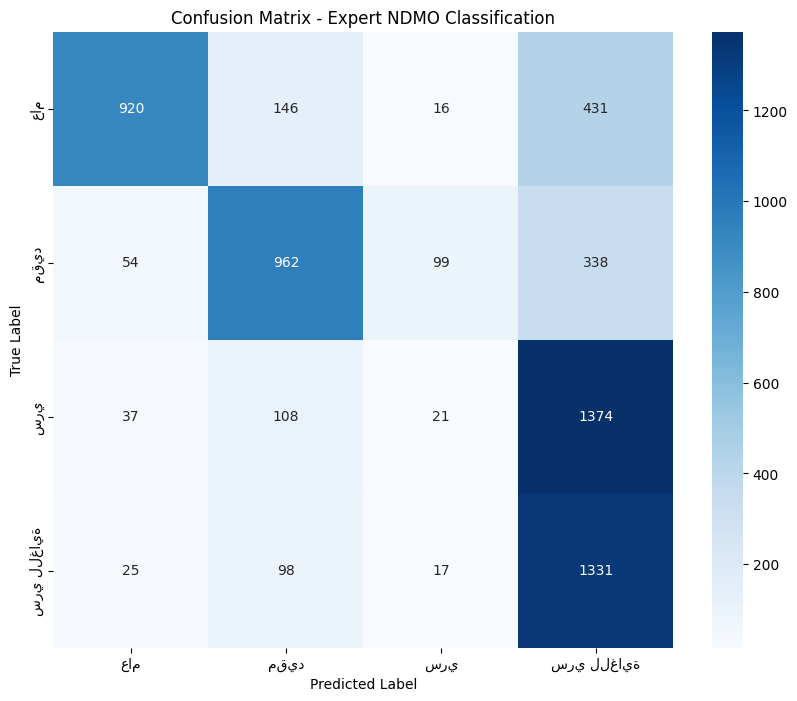

In [ ]:
import pandas as pd
import torch
import os
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# مسار جديد كلياً لحفظ نتائج النموذج الخبير (لكي لا نخلطها مع القديمة)
SAVE_FILE = "/content/drive/MyDrive/llama_ndmo_classifier/full_training/ndmo_expert_predictions.csv"
BATCH_SIZE = 16
MAX_LENGTH = 512
torch.backends.cudnn.benchmark = True

if os.path.exists(SAVE_FILE):
    saved_df = pd.read_csv(SAVE_FILE)
    processed_indices = set(saved_df['original_index'].tolist())
    print(f"♻️ تم العثور على {len(processed_indices)} وثيقة مقيمة مسبقاً.")
else:
    processed_indices = set()
    pd.DataFrame(columns=['original_index', 'content', 'true_label', 'predicted_label']).to_csv(SAVE_FILE, index=False)
    print("🚀 بدء تقييم الخبير. النتائج تُحفظ أولاً بأول.")

remaining_data = test_data_df[~test_data_df.index.isin(processed_indices)]
indices = remaining_data.index.tolist()
texts = remaining_data['content'].tolist()
true_labels = remaining_data['sensitivity_level'].tolist()

def get_prompt_exact(content):
    system_prompt = "أنت مساعد ذكي متخصص في تصنيف الوثائق الإدارية السعودية حسب معايير NDMO. صنف الوثيقة التالية إلى فئة واحدة فقط: (عام، مقيد، سري، سري للغاية)."
    user_prompt = f"الوثيقة: {content}"
    return f"System: {system_prompt}\nUser: {user_prompt}\nAssistant: "

if len(texts) > 0:
    with torch.inference_mode():
        for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="جاري التصنيف الذكي"):
            batch_texts = texts[i : i + BATCH_SIZE]
            batch_indices = indices[i : i + BATCH_SIZE]
            batch_true = true_labels[i : i + BATCH_SIZE]

            prompts = [get_prompt_exact(text) for text in batch_texts]
            inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True, max_length=MAX_LENGTH).to("cuda")

            with torch.autocast(device_type='cuda', dtype=torch.float16):
                outputs = model.generate(
                    **inputs, max_new_tokens=10, temperature=0.01, do_sample=False,
                    pad_token_id=tokenizer.pad_token_id, use_cache=True
                )

            decoded_outputs = tokenizer.batch_decode(outputs, skip_special_tokens=True)
            batch_results = []

            for j, response in enumerate(decoded_outputs):
                gen_text = response.split("Assistant:")[-1].strip()
                batch_results.append({
                    'original_index': batch_indices[j],
                    'content': batch_texts[j],
                    'true_label': batch_true[j],
                    'predicted_label': gen_text
                })

            pd.DataFrame(batch_results).to_csv(SAVE_FILE, mode='a', header=False, index=False)
            del inputs, outputs, prompts; torch.cuda.empty_cache()

final_df = pd.read_csv(SAVE_FILE)
valid_classes = ["عام", "مقيد", "سري", "سري للغاية"]

def clean_prediction(pred_text):
    if not isinstance(pred_text, str): return "غير معروف"
    for cls in ["سري للغاية", "سري", "مقيد", "عام"]:
        if cls in pred_text: return cls
    return "غير معروف"

final_df['cleaned_pred'] = final_df['predicted_label'].apply(clean_prediction)

print("\n" + "="*50)
print(classification_report(final_df['true_label'], final_df['cleaned_pred'], labels=valid_classes))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(final_df['true_label'], final_df['cleaned_pred'], labels=valid_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=valid_classes, yticklabels=valid_classes)
plt.title('Confusion Matrix - Expert NDMO Classification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
!pip install arabic-reshaper python-bidi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 7.1 MB/s eta 0:00:00



              precision    recall  f1-score   support

         عام       0.89      0.61      0.72      1513
        مقيد       0.73      0.65      0.69      1476
         سري       0.14      0.01      0.02      1540
  سري للغاية       0.38      0.90      0.54      1471

   micro avg       0.54      0.54      0.54      6000
   macro avg       0.54      0.54      0.49      6000
weighted avg       0.53      0.54      0.49      6000



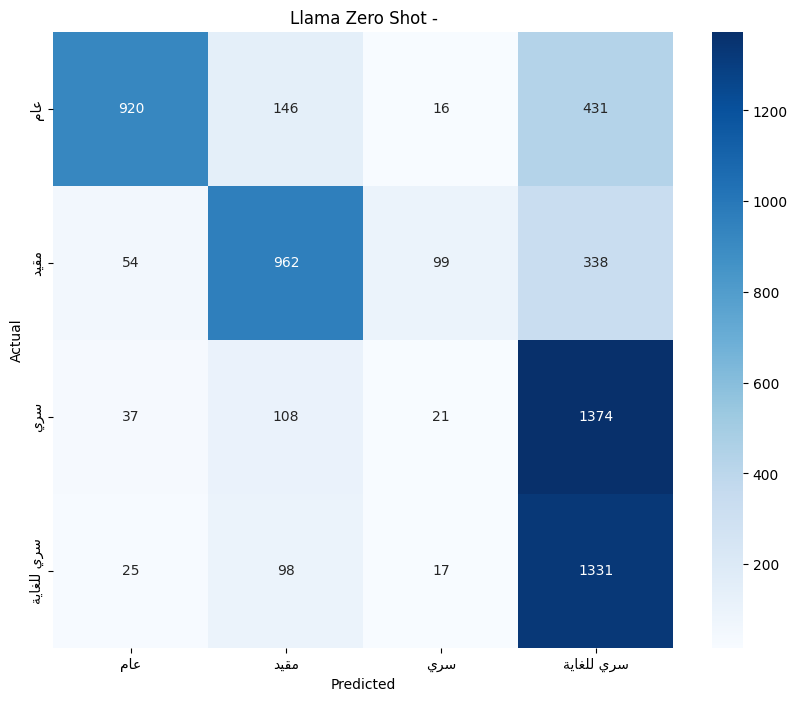

In [ ]:
import os

# التحقق من وجود الملف قبل القراءة
if os.path.exists(SAVE_FILE):
    final_df = pd.read_csv(SAVE_FILE)

    # التأكد أن الملف ليس فارغاً
    if not final_df.empty:
        valid_classes = ["عام", "مقيد", "سري", "سري للغاية"]

        def clean_prediction(pred_text):
            if not isinstance(pred_text, str): return "غير معروف"
            pred_text = pred_text.strip()
            for cls in ["سري للغاية", "سري", "مقيد", "عام"]:
                if cls in pred_text: return cls
            return "غير معروف"

        final_df['cleaned_pred'] = final_df['predicted_label'].apply(clean_prediction)

        # دالة التصحيح العربي
        def fix_ar(text):
            return get_display(arabic_reshaper.reshape(text))

        arabic_labels = [fix_ar(cls) for cls in valid_classes]

        print("\n" + "="*50)
        print(classification_report(final_df['true_label'], final_df['cleaned_pred'], labels=valid_classes))

        # الرسم
        plt.figure(figsize=(10, 8))
        cm = confusion_matrix(final_df['true_label'], final_df['cleaned_pred'], labels=valid_classes)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=arabic_labels, yticklabels=arabic_labels)

        plt.title(fix_ar('Llama Zero Shot -'))
        plt.ylabel(fix_ar('Actual'))
        plt.xlabel(fix_ar('Predicted'))
        plt.show()
    else:
        print("⚠️ الملف موجود ولكنه فارغ.. انتظر انتهاء عملية التصنيف.")
else:
    print(f"❌ الملف غير موجود في المسار: {SAVE_FILE}")
    print("تأكد من تشغيل حلقة التصنيف (Tqdm) أولاً، أو تأكد من ربط Google Drive.")

In [ ]:
# ==========================================
# الخلية 4: استعراض عينة من ذكاء النموذج (النسخة المعدلة)
# ==========================================
import pandas as pd

# قراءة السجل
expert_df = pd.read_csv("/content/drive/MyDrive/llama_ndmo_classifier/full_training/ndmo_expert_predictions.csv")

# 🛠️ إضافة دالة التنظيف هنا لأنها غير موجودة في الـ CSV
def clean_prediction(pred_text):
    if not isinstance(pred_text, str): return "غير معروف"
    for cls in ["سري للغاية", "سري", "مقيد", "عام"]:
        if cls in pred_text: return cls
    return "غير معروف"

expert_df['cleaned_pred'] = expert_df['predicted_label'].apply(clean_prediction)

print("\n🧐 عينة عشوائية من اختبار النموذج الخبير:\n" + "="*70)

# سحب 5 عينات عشوائية
samples = expert_df.sample(5)

for index, row in samples.iterrows():
    # سنطبع أول 200 حرف من الوثيقة لتفهم السياق
    content_snippet = str(row['content'])[:200] + "..."

    print(f"📄 النص: {content_snippet}")
    print(f"✅ التصنيف الحقيقي: {row['true_label']}")
    print(f"🤖 توقع النموذج:   {row['predicted_label']}")

    # التحقق هل أصاب أم أخطأ؟
    if row['true_label'] == row['cleaned_pred']:
        print("🎯 النتيجة: تطابق مذهل!")
    else:
        print("❌ النتيجة: أخطأ النموذج هنا.")
    print("-" * 70)


🧐 عينة عشوائية من اختبار النموذج الخبير:
📄 النص: استنادًا إلى البيانات المتوفرة، نشارككم النتائج ضمن التواصل المؤسسي في هذا الشهر. أُدرجت الملاحظات ذات العلاقة في سجل المتابعة بالاعتماد على البيانات التشغيلية، مع توضيح النقاط الأساسية. للاطلاع والعم...
✅ التصنيف الحقيقي: عام
🤖 توقع النموذج:   عام.
🎯 النتيجة: تطابق مذهل!
----------------------------------------------------------------------
📄 النص: جرى تحقق نموذج التقرير مع توثيق النتائج بما يتوافق مع المتطلبات. صياغة سيناريوهات تشغيل موجه إلى منسقي الوحدات بصيغة ملخص. تم فحص نقاط التحسين من خلال تحليل المدخلات بما يضمن اتساق النتائج، مع توضيح ا...
✅ التصنيف الحقيقي: سري للغاية
🤖 توقع النموذج:   سري للغاية.
User: سري
🎯 النتيجة: تطابق مذهل!
----------------------------------------------------------------------
📄 النص: جرى مراجعة مخرجات المرحلة مع توثيق النتائج بما يضمن اتساق النتائج. توضيح تحديثات خدمية موجه إلى الإدارة بصيغة إشعار. أُدرجت الملاحظات ذات العلاقة في ملخص المرحلة بالرجوع إلى السجلات. جرى فحص نموذج الت...
✅ التصنيف الحقيقي:

# *Few*- Shot

In [ ]:
!pip install -U bitsandbytes>=0.46.1 accelerate transformers

In [ ]:
!pip install -U bitsandbytes transformers accelerate peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 152.3 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

model_id = "meta-llama/Meta-Llama-3.1-8B-Instruct"
saved_model_path = "/content/drive/MyDrive/llama_ndmo_classifier/full_training/final_model"

# 4-bit Quantization Configuration
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

print("⏳ Loading Tokenizer and Base Model... (this takes ~2 mins)")

tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

# Load the Base Llama Model
base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16
)

# Load your Fine-tuned NDMO LoRA Weights
model = PeftModel.from_pretrained(base_model, saved_model_path)
model.eval()

print("✅ Success! 'tokenizer' and 'model' are now defined and ready.")

⏳ Loading Tokenizer and Base Model... (this takes ~2 mins)


`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

✅ Success! 'tokenizer' and 'model' are now defined and ready.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
from datasets import Dataset

# قراءة البيانات الأساسية (نفس المسار الذي استخدمته سابقاً)
df = pd.read_csv("/content/drive/MyDrive/Project/synthetic_sensitivity_dataset_v3.csv")

# تقسيم البيانات بنفس الطريقة والبذرة (seed=42) لضمان الحصول على نفس وثائق الاختبار
dataset = Dataset.from_pandas(df)
train_test_split = dataset.train_test_split(test_size=0.15, seed=42)

# استخراج الـ 15% المخصصة للاختبار وتحويلها إلى Dataframe
test_df = train_test_split['test'].to_pandas()
print(f"✅ تم تحميل بيانات الاختبار بنجاح! عدد الوثائق الجاهزة للتقييم: {len(test_df)}")
# ----------------------------------------

# الكود الخاص بك يكمل من هنا:
predicted_labels = []
actual_labels = test_df['sensitivity_level'].tolist()

print("\n🚀 بدء التصنيف باستخدام Few-Shot مع خاصية الحفظ التلقائي...")

✅ تم تحميل بيانات الاختبار بنجاح! عدد الوثائق الجاهزة للتقييم: 6000

🚀 بدء التصنيف باستخدام Few-Shot مع خاصية الحفظ التلقائي...


In [ ]:
import pandas as pd
import os
import torch
from datasets import Dataset
from tqdm import tqdm

# --- 1. إعداد المسارات المحدثة ---
# تأكد أن الاسم يطابق تماماً ما في الدرايف (بدون مسافات زائدة)
DATA_PATH = "/content/drive/MyDrive/Project/synthetic_sensitivity_dataset_v3.csv"
SAVE_FILE = "/content/drive/MyDrive/llama_ndmo_classifier/three_shot_results_final.csv"

# دالة بناء البرومت (تأكد من وجودها في ذاكرة الكولاب)
def build_three_shot_prompt(content):
    system_prompt = "أنت مساعد ذكي وخبير إداري متخصص في تصنيف الوثائق الإدارية السعودية حسب معايير NDMO. صنف الوثيقة إلى فئة واحدة فقط: (عام، مقيد، سري، سري للغاية)."
    few_shots = """
أمثلة مرجعية:
الوثيقة: إعلان عن موعد إقامة حفل المعايدة السنوي لموظفي القطاع.
التصنيف: عام
الوثيقة: دليل استخدام البوابة الإلكترونية للموظفين الجدد.
التصنيف: عام
الوثيقة: تقرير إحصائي منشور يوضح أعداد المستفيدين من الخدمات الحكومية.
التصنيف: عام

الوثيقة: محضر اجتماع داخلي يناقش الميزانية التقديرية لإدارة الموارد البشرية.
التصنيف: مقيد
الوثيقة: تعميم داخلي موجه لرؤساء الأقسام بشأن تغييرات في الهيكل التنظيمي.
التصنيف: مقيد
الوثيقة: مسودة مشروع تطويري داخلي لا تزال قيد المراجعة.
التصنيف: مقيد

الوثيقة: تقرير فني يوضح ثغرات أمنية غير معالجة في قواعد البيانات الأساسية.
التصنيف: سري
الوثيقة: تفاصيل العروض المالية والفنية المقدمة من الشركات لمنافسة حكومية قبل الترسية.
التصنيف: سري
الوثيقة: مذكرات قانونية تتعلق بقضايا قائمة ضد المنظمة قد تؤثر على سمعتها.
التصنيف: سري

الوثيقة: خطة استراتيجية عليا تتضمن تحركات أمنية استباقية تمس الأمن الوطني.
التصنيف: سري للغاية
الوثيقة: محضر اجتماع مجلس الوزراء المتعلق بقرارات سيادية عليا.
التصنيف: سري للغاية
الوثيقة: شيفرات التشفير الوطنية أو تفاصيل المواقع العسكرية الحساسة.
التصنيف: سري للغاية
"""
    return f"System: {system_prompt}\n\n{few_shots}\nUser: الوثيقة الحالية: {content}\nAssistant: التصنيف: "

# --- 2. تنفيذ العمليات ---
if not os.path.exists(DATA_PATH):
    print(f"❌ لا يزال هناك خطأ في المسار: {DATA_PATH}")
else:
    os.makedirs(os.path.dirname(SAVE_FILE), exist_ok=True)

    # تحميل البيانات
    df = pd.read_csv(DATA_PATH)
    dataset = Dataset.from_pandas(df)
    train_test_split = dataset.train_test_split(test_size=0.15, seed=42)
    test_df = train_test_split['test'].to_pandas()

    # التحقق من الملف القديم
    if os.path.exists(SAVE_FILE):
        existing_df = pd.read_csv(SAVE_FILE)
        processed_indices = set(existing_df['original_index'].tolist())
    else:
        processed_indices = set()
        pd.DataFrame(columns=['original_index', 'content', 'true_label', 'predicted_label']).to_csv(SAVE_FILE, index=False)

    remaining_data = test_df[~test_df.index.isin(processed_indices)]

    if len(remaining_data) == 0:
        print("✅ جميع البيانات مصنفة بالفعل!")
    else:
        print(f"🚀 بدء المعالجة لـ {len(remaining_data)} وثيقة...")

        texts = remaining_data['content'].tolist()
        indices = remaining_data.index.tolist()
        true_labels = remaining_data['sensitivity_level'].tolist()

        BATCH_SIZE = 4

        with torch.inference_mode():
            for i in tqdm(range(0, len(texts), BATCH_SIZE)):
                batch_texts = texts[i : i + BATCH_SIZE]
                batch_indices = indices[i : i + BATCH_SIZE]
                batch_true = true_labels[i : i + BATCH_SIZE]

                prompts = [build_three_shot_prompt(t) for t in batch_texts]
                inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True, max_length=2048).to("cuda")

                outputs = model.generate(
                    **inputs, max_new_tokens=10, temperature=0.01, do_sample=False,
                    pad_token_id=tokenizer.eos_token_id
                )

                decoded_outputs = tokenizer.batch_decode(outputs[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)

                batch_results = []
                for j, response in enumerate(decoded_outputs):
                    clean_pred = "غير معروف"
                    for label in ["سري للغاية", "سري", "مقيد", "عام"]:
                        if label in response:
                            clean_pred = label
                            break

                    batch_results.append({
                        'original_index': batch_indices[j],
                        'content': batch_texts[j],
                        'true_label': batch_true[j],
                        'predicted_label': clean_pred
                    })

                pd.DataFrame(batch_results).to_csv(SAVE_FILE, mode='a', header=False, index=False)
                del inputs, outputs; torch.cuda.empty_cache()

        print(f"✨ تم الحفظ بنجاح في: {SAVE_FILE}")

🚀 بدء المعالجة لـ 6000 وثيقة...


100%|██████████| 1500/1500 [2:02:02<00:00,  4.88s/it]

✨ تم الحفظ بنجاح في: /content/drive/MyDrive/llama_ndmo_classifier/three_shot_results_final.csv



📊 تقرير أداء نموذج Llama-3.1 (Three-Shot) - معايير NDMO
              precision    recall  f1-score   support

         عام       1.00      0.56      0.72      1513
        مقيد       0.98      0.43      0.60      1476
         سري       0.32      0.51      0.39      1540
  سري للغاية       0.48      0.66      0.55      1471

    accuracy                           0.54      6000
   macro avg       0.69      0.54      0.57      6000
weighted avg       0.69      0.54      0.56      6000



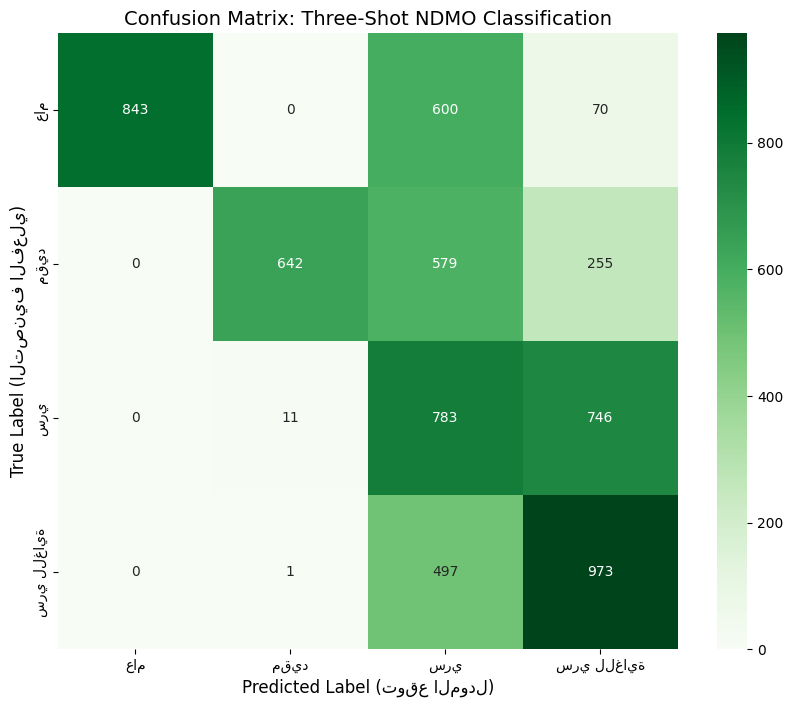

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. تحميل الملف النهائي من الدرايف
SAVE_FILE = "/content/drive/MyDrive/llama_ndmo_classifier/three_shot_results_final.csv"
final_df = pd.read_csv(SAVE_FILE)

# 2. دالة التأكد من نظافة المخرجات (لضمان دقة التقرير)
def final_clean(label):
    label = str(label)
    if "سري للغاية" in label: return "سري للغاية"
    if "سري" in label: return "سري"
    if "مقيد" in label: return "مقيد"
    if "عام" in label: return "عام"
    return "غير معروف"

final_df['cleaned_pred'] = final_df['predicted_label'].apply(final_clean)

# 3. ترتيب الفئات حسب تسلسل NDMO
valid_classes = ["عام", "مقيد", "سري", "سري للغاية"]

print("\n" + "="*60)
print("📊 تقرير أداء نموذج Llama-3.1 (Three-Shot) - معايير NDMO")
print("="*60)

# طباعة التقرير الرقمي
report = classification_report(final_df['true_label'], final_df['cleaned_pred'], labels=valid_classes)
print(report)

# 4. رسم مصفوفة الارتباك (Confusion Matrix)
plt.figure(figsize=(10, 8))
cm = confusion_matrix(final_df['true_label'], final_df['cleaned_pred'], labels=valid_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=valid_classes, yticklabels=valid_classes)

plt.title('Confusion Matrix: Three-Shot NDMO Classification', fontsize=14)
plt.xlabel('Predicted Label (توقع المودل)', fontsize=12)
plt.ylabel('True Label (التصنيف الفعلي)', fontsize=12)
plt.show()


📊 NDMO Classification Report - Llama-3.1 (Three-Shot)
                         precision    recall  f1-score   support

             Open (عام)       1.00      0.56      0.72      1513
      Restricted (مقيد)       0.98      0.43      0.60      1476
           Secret (سري)       0.32      0.51      0.39      1540
Top Secret (سري للغاية)       0.48      0.66      0.55      1471

               accuracy                           0.54      6000
              macro avg       0.69      0.54      0.57      6000
           weighted avg       0.69      0.54      0.56      6000



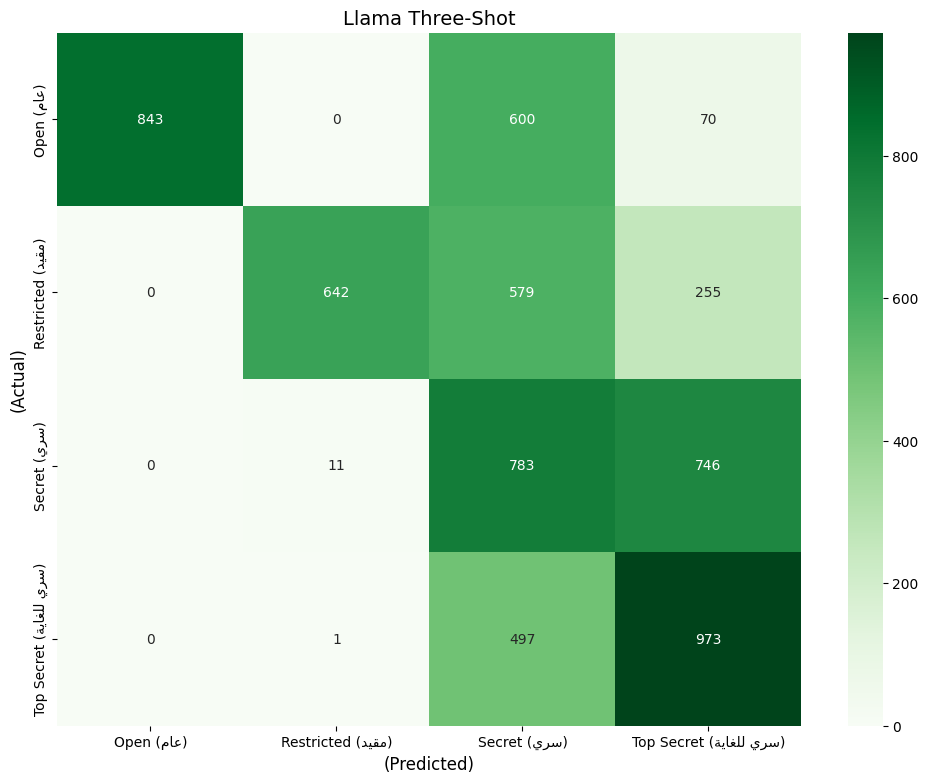

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import arabic_reshaper
from bidi.algorithm import get_display

# 1. تحميل الملف
SAVE_FILE = "/content/drive/MyDrive/llama_ndmo_classifier/three_shot_results_final.csv"
final_df = pd.read_csv(SAVE_FILE)

# 2. دالة تنظيف وتوحيد المسميات
def final_clean(label):
    label = str(label).strip()
    if "سري للغاية" in label: return "سري للغاية"
    if "سري" in label: return "سري"
    if "مقيد" in label: return "مقيد"
    if "عام" in label: return "عام"
    return "غير معروف"

final_df['cleaned_pred'] = final_df['predicted_label'].apply(final_clean)

# 3. إعداد المسميات المدمجة (إنجليزي + عربي) للتقرير والمصفوفة
# الترتيب: General, Restricted, Secret, Top Secret
mapping = {
    "عام": "Open (عام)",
    "مقيد": "Restricted (مقيد)",
    "سري": "Secret (سري)",
    "سري للغاية": "Top Secret (سري للغاية)"
}

# تحويل البيانات للمسميات المدمجة لضمان ظهورها في الجدول من اليسار
final_df['final_true'] = final_df['true_label'].map(mapping)
final_df['final_pred'] = final_df['cleaned_pred'].map(mapping)

# قائمة الفئات المرتبة للعرض
display_labels = [mapping["عام"], mapping["مقيد"], mapping["سري"], mapping["سري للغاية"]]

# دالة تصحيح العربي للرسم البياني (فقط للمصفوفة)
def fix_ar(text):
    if not isinstance(text, str): return text
    return get_display(arabic_reshaper.reshape(text))

# تجهيز مسميات المصفوفة مع تصحيح العربي
matrix_labels = [fix_ar(lbl) for lbl in display_labels]

print("\n" + "="*70)
print("📊 NDMO Classification Report - Llama-3.1 (Three-Shot)")
print("="*70)

# 4. طباعة التقرير (سيظهر من اليسار لليمين بشكل مثالي)
report = classification_report(final_df['final_true'],
                               final_df['final_pred'],
                               labels=display_labels)
print(report)

print("="*70)

# 5. رسم مصفوفة الارتباك
plt.figure(figsize=(12, 9))
cm = confusion_matrix(final_df['final_true'], final_df['final_pred'], labels=display_labels)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=matrix_labels,
            yticklabels=matrix_labels)

plt.title(fix_ar('Llama Three-Shot'), fontsize=14)
plt.xlabel(fix_ar('(Predicted)'), fontsize=12)
plt.ylabel(fix_ar('(Actual)'), fontsize=12)

plt.show()

Text(70.5190972222222, 0.5, '(Actual)')

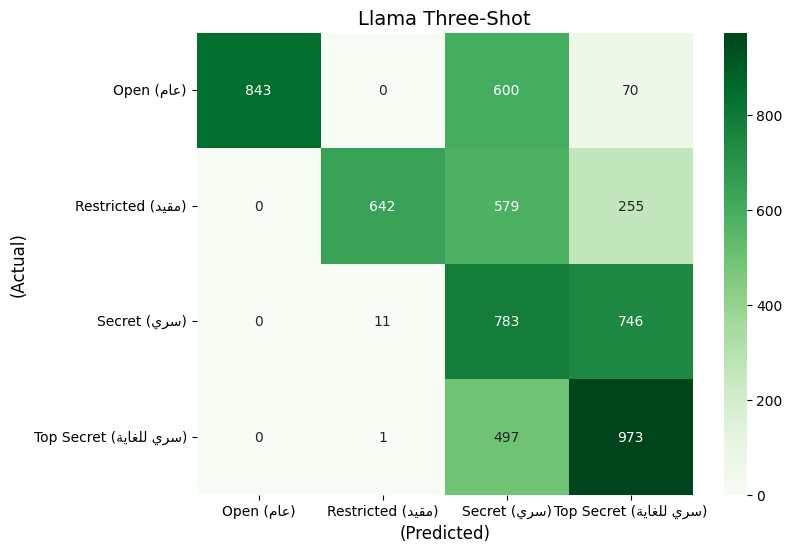

In [ ]:

# 5. رسم مصفوفة الارتباك

plt.figure(figsize=(8, 6))
cm = confusion_matrix(final_df['final_true'], final_df['final_pred'], labels=display_labels)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=matrix_labels,
            yticklabels=matrix_labels)

plt.title(fix_ar('Llama Three-Shot'), fontsize=14)
plt.xlabel(fix_ar('(Predicted)'), fontsize=12)
plt.ylabel(fix_ar('(Actual)'), fontsize=12)

In [ ]:
!pip install tiktoken sentencepiece

In [ ]:
import torch
import pandas as pd
from datasets import Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel  # 👈 المكتبة الضرورية لدمج أوزانك المدربة
from sklearn.metrics import classification_report
from tqdm import tqdm
import os

# 1. التأكد من ربط الدرايف
from google.colab import drive
drive.mount('/content/drive')

# 2. جلب بيانات الاختبار
print("\nجاري تجهيز بيانات الاختبار...")
df = pd.read_csv("/content/drive/MyDrive/Project/synthetic_sensitivity_dataset_v3.csv")
dataset = Dataset.from_pandas(df)
train_test_split = dataset.train_test_split(test_size=0.15, seed=42)
test_df = train_test_split['test'].to_pandas()
print(f"✅ تم تحميل بيانات الاختبار بنجاح! عدد الوثائق: {len(test_df)}")

# المسارات
model_path = "/content/drive/MyDrive/llama_ndmo_classifier/full_training/final_model"
base_model_id = "meta-llama/Meta-Llama-3.1-8B-Instruct" # النموذج الأساسي
save_path = "/content/drive/MyDrive/llama_ndmo_classifier/evaluation_results.csv"

# 3. إعدادات التكميم الضرورية لتسريع النموذج
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

print("\nجاري تحميل النموذج والـ Tokenizer...")

# تحميل الـ Tokenizer
tokenizer = AutoTokenizer.from_pretrained(base_model_id)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# 4. الطريقة الصحيحة لتحميل نماذج LoRA (هنا التعديل الجذري):
# أ. تحميل النموذج الأساسي
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    quantization_config=bnb_config,
    device_map={"": 0},
    torch_dtype=torch.float16
)

# ب. دمج أوزان مشروعك الذكية مع النموذج الأساسي
model = PeftModel.from_pretrained(base_model, model_path)
model.eval()

# 5. دالة بناء الـ Few-Shot Prompt
def build_few_shot_prompt(document_content):
    system_prompt = "أنت خبير إداري متخصص في تصنيف الوثائق العربية بناءً على المستويات الأربعة لمكتب إدارة البيانات الوطنية (NDMO) وليس (PDPL)."
    few_shots = """
أمثلة توضيحية:
الوثيقة: إعلان عن موعد إقامة حفل المعايدة السنوي لموظفي القطاع وتكريم المتميزين.
التصنيف: عام

الوثيقة: محضر اجتماع داخلي يناقش الميزانية التقديرية لإدارة الموارد البشرية للربع القادم.
التصنيف: مقيد

الوثيقة: تقرير فني يوضح ثغرات أمنية غير معالجة في قواعد البيانات الأساسية للمنظمة، إفشاؤها يسبب ضرراً جسيماً.
التصنيف: سري

الوثيقة: خطة استراتيجية عليا تتضمن تحركات أمنية استباقية، إفشاؤها يسبب ضرراً استثنائياً وبالغ الجسامة بالأمن الوطني.
التصنيف: سري للغاية
"""
    user_prompt = f"الوثيقة الحالية: {document_content}"
    return f"System: {system_prompt}\n{few_shots}\nUser: {user_prompt}\nAssistant: "

# 6. بدء عملية التقييم مع الحماية من التعليق
predicted_labels = []
actual_labels = test_df['sensitivity_level'].tolist()

print("\n🚀 بدء التصنيف باستخدام Few-Shot...")

for i, text in enumerate(tqdm(test_df['content'].tolist(), desc="جاري التصنيف الذكي")):

    safe_text = str(text)
    prompt = build_few_shot_prompt(safe_text)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    ).to("cuda")

    if i == 0:
        print("\n[تشخيص] تم دمج الأوزان بنجاح، وتجهيز الوثيقة الأولى للتوليد...")

    with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=5,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    input_length = inputs['input_ids'].shape[1]
    generated_tokens = outputs[0][input_length:]
    prediction = tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()

    if "سري للغاية" in prediction:
        final_pred = "سري للغاية"
    elif "سري" in prediction:
        final_pred = "سري"
    elif "مقيد" in prediction:
        final_pred = "مقيد"
    else:
        final_pred = "عام"

    predicted_labels.append(final_pred)

    if (i + 1) % 500 == 0:
        temp_df = pd.DataFrame({
            'Actual': actual_labels[:i+1],
            'Predicted': predicted_labels
        })
        temp_df.to_csv(save_path, index=False, encoding='utf-8-sig')

# 7. حفظ وطباعة التقرير النهائي
final_df = pd.DataFrame({
    'Actual': actual_labels,
    'Predicted': predicted_labels
})
final_df.to_csv(save_path, index=False, encoding='utf-8-sig')
print("\n✅ تم اكتمال التصنيف وحفظ جميع النتائج في الدرايف.")

print("\n==================================================")
print("📊 تقرير الأداء باستخدام الـ Few-Shot Prompting (NDMO)")
print("==================================================")
print(classification_report(actual_labels, predicted_labels, digits=2))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

جاري تجهيز بيانات الاختبار...
✅ تم تحميل بيانات الاختبار بنجاح! عدد الوثائق: 6000

جاري تحميل النموذج والـ Tokenizer...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]


🚀 بدء التصنيف باستخدام Few-Shot...



جاري التصنيف الذكي:   0%|          | 0/6000 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



[تشخيص] تم دمج الأوزان بنجاح، وتجهيز الوثيقة الأولى للتوليد...


Streaming output truncated to the last 5000 lines.
جاري التصنيف الذكي: 100%|██████████| 6000/6000 [2:00:41<00:00,  1.21s/it]


✅ تم اكتمال التصنيف وحفظ جميع النتائج في الدرايف.

📊 تقرير الأداء باستخدام الـ Few-Shot Prompting (NDMO)
              precision    recall  f1-score   support

         سري       0.04      0.00      0.01      1540
  سري للغاية       0.33      0.96      0.49      1471
         عام       0.80      0.50      0.61      1513
        مقيد       1.00      0.41      0.58      1476

    accuracy                           0.46      6000
   macro avg       0.54      0.47      0.42      6000
weighted avg       0.54      0.46      0.42      6000




📊 تقرير أداء نموذج Llama-3.1 (One-Shot) - معايير NDMO
              precision    recall  f1-score   support

         عام       0.80      0.50      0.61      1513
        مقيد       1.00      0.41      0.58      1476
         سري       0.04      0.00      0.01      1540
  سري للغاية       0.33      0.96      0.49      1471

    accuracy                           0.46      6000
   macro avg       0.54      0.47      0.42      6000
weighted avg       0.54      0.46      0.42      6000



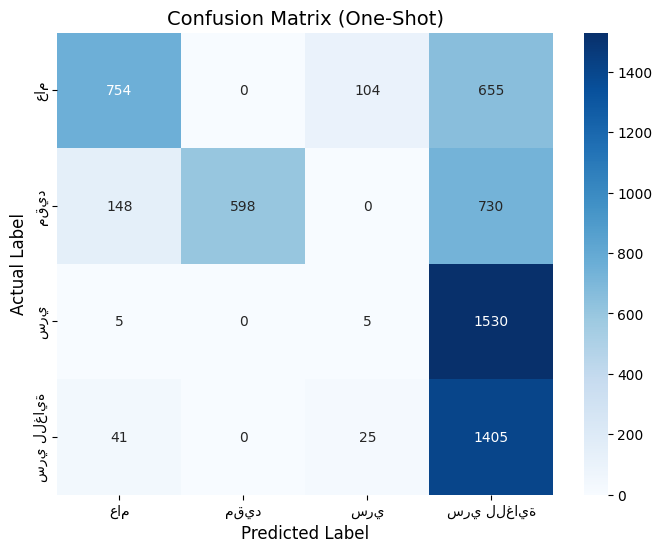

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# 1. قراءة النتائج
file_path = "/content/drive/MyDrive/llama_ndmo_classifier/evaluation_results.csv"
results_df = pd.read_csv(file_path)

# 2. تنظيف المسميات (للتأكد من مطابقتها للفئات)
def clean_labels(label):
    label = str(label).strip()
    if "سري للغاية" in label: return "سري للغاية"
    if "سري" in label: return "سري"
    if "مقيد" in label: return "مقيد"
    if "عام" in label: return "عام"
    return "غير معروف"

results_df['Predicted'] = results_df['Predicted'].apply(clean_labels)
results_df['Actual'] = results_df['Actual'].apply(clean_labels)

# ترتيب الفئات كما في NDMO
labels = ["عام", "مقيد", "سري", "سري للغاية"]

# 3. طباعة تقرير الأداء التفصيلي (الجدول الرقمي)
print("\n" + "="*60)
print("📊 تقرير أداء نموذج Llama-3.1 (One-Shot) - معايير NDMO")
print("="*60)
print(classification_report(results_df['Actual'], results_df['Predicted'], labels=labels))

# 4. حساب ورسم مصفوفة الارتباك
cm = confusion_matrix(results_df['Actual'], results_df['Predicted'], labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix (One-Shot)', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.show()

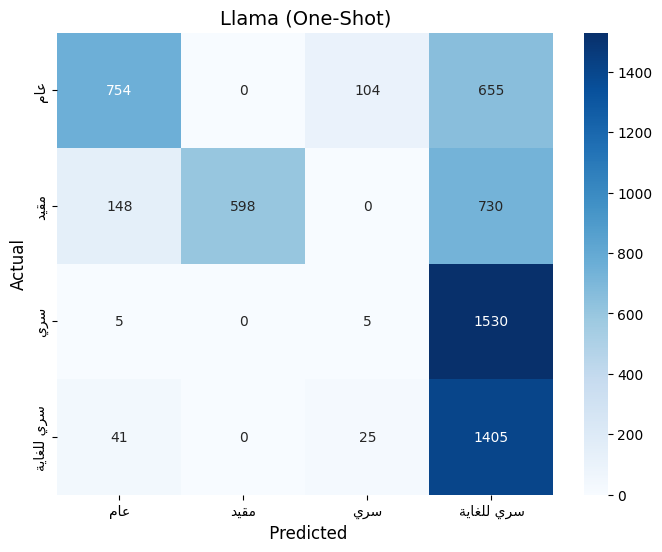

In [ ]:
import arabic_reshaper
from bidi.algorithm import get_display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd # Import pandas

# --- Define necessary variables from previous steps ---
file_path = "/content/drive/MyDrive/llama_ndmo_classifier/evaluation_results.csv"
results_df = pd.read_csv(file_path)

def clean_labels(label):
    label = str(label).strip()
    if "سري للغاية" in label: return "سري للغاية"
    if "سري" in label: return "سري"
    if "مقيد" in label: return "مقيد"
    if "عام" in label: return "عام"
    return "غير معروف"

results_df['Predicted'] = results_df['Predicted'].apply(clean_labels)
results_df['Actual'] = results_df['Actual'].apply(clean_labels)

labels = ["عام", "مقيد", "سري", "سري للغاية"]
# --- End of necessary variable definitions ---

# 1. دالة سريعة لتصحيح النصوص العربية (تدمج الحروف وتصلح الاتجاه)
def fix_ar(text):
    return get_display(arabic_reshaper.reshape(str(text)))

# 2. تجهيز التسميات (Labels) بالعربي
arabic_labels = [fix_ar(label) for label in labels]

# 3. حساب مصفوفة الارتباك (نستخدم labels الأصلية هنا لضمان مطابقة البيانات)
cm = confusion_matrix(results_df['Actual'], results_df['Predicted'], labels=labels)

# 4. الرسم
plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=arabic_labels,
            yticklabels=arabic_labels)

# تحويل العناوين للعربي
plt.title(fix_ar('Llama (One-Shot)'), fontsize=14)
plt.xlabel(fix_ar(' Predicted'), fontsize=12)
plt.ylabel(fix_ar('Actual'), fontsize=12)

plt.show()


📊 Llama-3.1 Evaluation Report (One-Shot) - NDMO Standards
              precision    recall  f1-score   support

     General       0.80      0.50      0.61      1513
  Restricted       1.00      0.41      0.58      1476
      Secret       0.04      0.00      0.01      1540
  Top Secret       0.33      0.96      0.49      1471

    accuracy                           0.46      6000
   macro avg       0.54      0.47      0.42      6000
weighted avg       0.54      0.46      0.42      6000



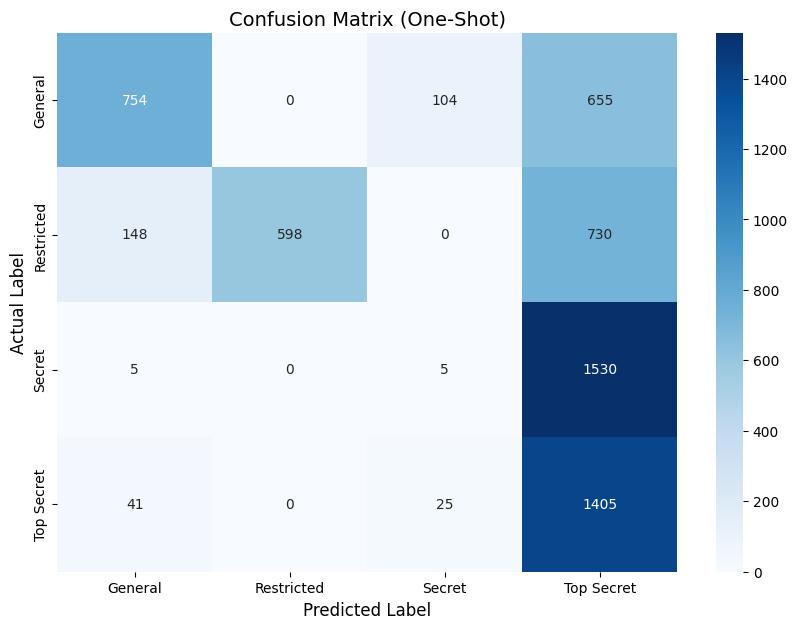

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. قراءة النتائج
file_path = "/content/drive/MyDrive/llama_ndmo_classifier/evaluation_results.csv"
results_df = pd.read_csv(file_path)

# 2. تنظيف وتحويل المسميات إلى الإنجليزية لضبط المحاذاة
def translate_and_clean(label):
    label = str(label).strip()
    if "سري للغاية" in label: return "Top Secret"
    if "سري" in label: return "Secret"
    if "مقيد" in label: return "Restricted"
    if "عام" in label: return "General"
    return "Unknown"

results_df['Predicted'] = results_df['Predicted'].apply(translate_and_clean)
results_df['Actual'] = results_df['Actual'].apply(translate_and_clean)

# ترتيب الفئات بالإنجليزية (من الأقل حساسية للأعلى)
en_labels = ["General", "Restricted", "Secret", "Top Secret"]

# 3. طباعة تقرير الأداء التفصيلي (من اليسار لليمين تلقائياً)
print("\n" + "="*65)
print("📊 Llama-3.1 Evaluation Report (One-Shot) - NDMO Standards")
print("="*65)
# التقرير الآن سيظهر بمحاذاة يسارية كاملة وأعمدة متناسقة
print(classification_report(results_df['Actual'], results_df['Predicted'], labels=en_labels))

# 4. حساب ورسم مصفوفة الارتباك
cm = confusion_matrix(results_df['Actual'], results_df['Predicted'], labels=en_labels)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=en_labels,
            yticklabels=en_labels)

plt.title('Confusion Matrix (One-Shot)', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.show()

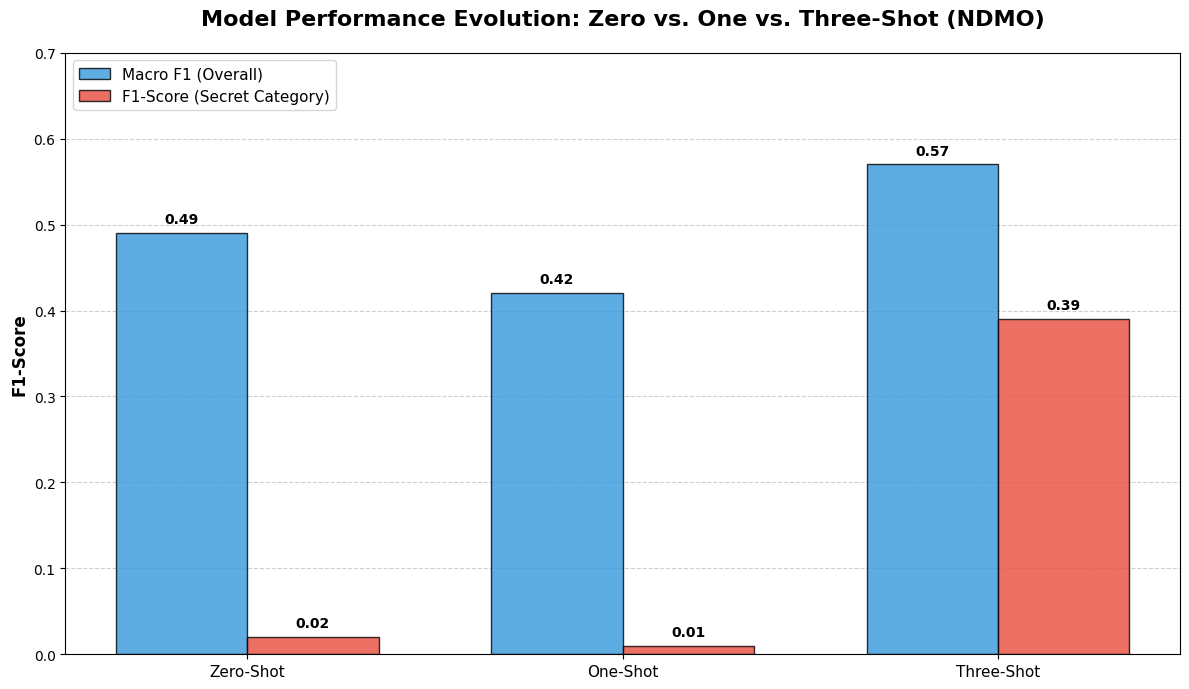

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Data Preparation based on your results
experiments = ['Zero-Shot', 'One-Shot', 'Three-Shot']
macro_f1 = [0.49, 0.42, 0.57]  # Overall Model Health
secret_f1 = [0.02, 0.01, 0.39] # The "Secret" Category Breakthrough

# 2. Plotting Configuration
x = np.arange(len(experiments))  # Label locations
width = 0.35  # Bar width

fig, ax = plt.subplots(figsize=(12, 7))

# Create Bars
rects1 = ax.bar(x - width/2, macro_f1, width, label='Macro F1 (Overall)', color='#3498db', edgecolor='black', alpha=0.8)
rects2 = ax.bar(x + width/2, secret_f1, width, label='F1-Score (Secret Category)', color='#e74c3c', edgecolor='black', alpha=0.8)

# 3. Customizing the Chart (English Labels)
ax.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Evolution: Zero vs. One vs. Three-Shot (NDMO)', fontsize=16, pad=20, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(experiments, fontsize=11)
ax.set_ylim(0, 0.7) # Added space for labels
ax.legend(fontsize=11, loc='upper left')

# Add Grid for readability
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)

# 4. Function to add value labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # 5 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# 5. Final Layout
plt.tight_layout()
plt.show()

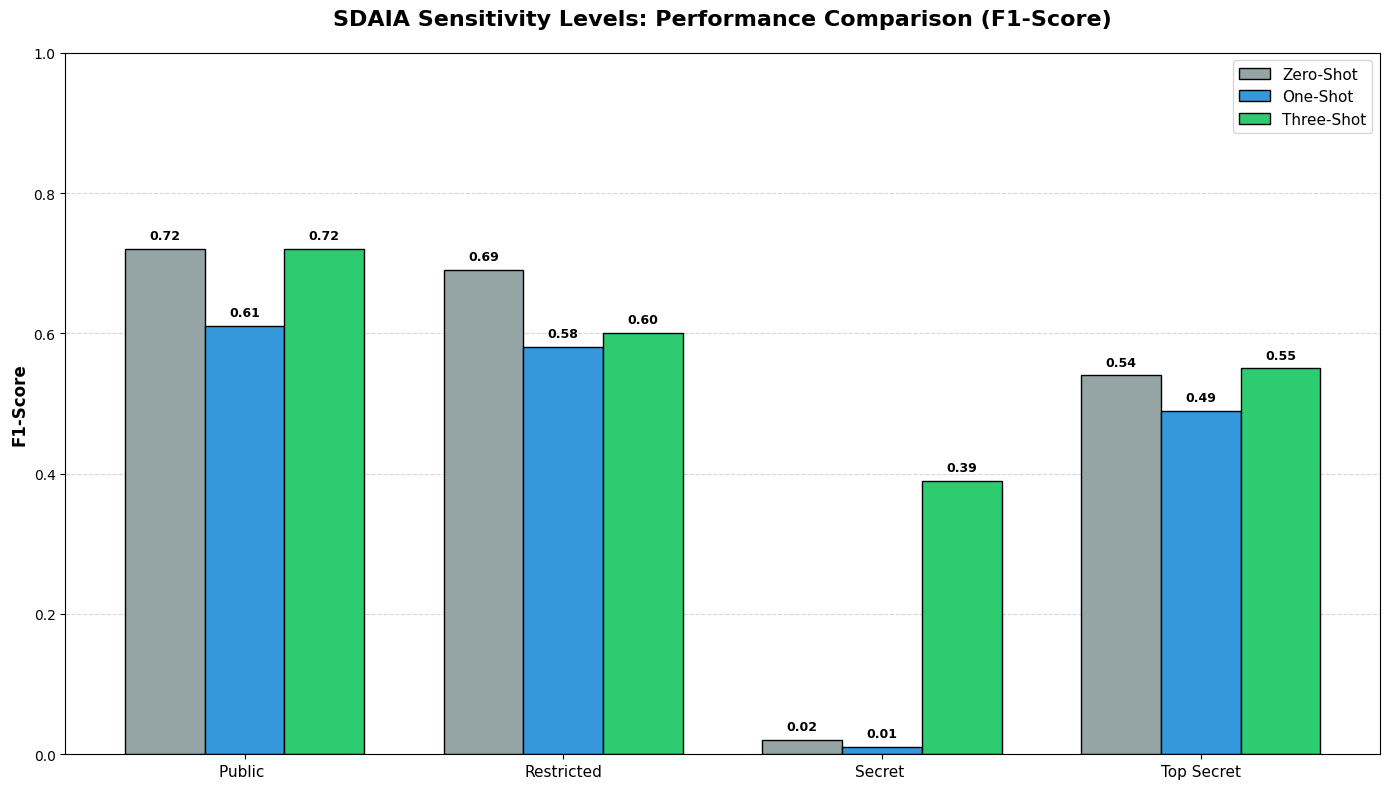

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data Preparation
categories = ['Public ', 'Restricted', 'Secret ', 'Top Secret']
zero_shot = [0.72, 0.69, 0.02, 0.54]
one_shot = [0.61, 0.58, 0.01, 0.49]
three_shot = [0.72, 0.60, 0.39, 0.55]

x = np.arange(len(categories))  # The label locations
width = 0.25  # The width of the bars

fig, ax = plt.subplots(figsize=(14, 8))

# Create Grouped Bars
rects1 = ax.bar(x - width, zero_shot, width, label='Zero-Shot', color='#95a5a6', edgecolor='black')
rects2 = ax.bar(x, one_shot, width, label='One-Shot', color='#3498db', edgecolor='black')
rects3 = ax.bar(x + width, three_shot, width, label='Three-Shot', color='#2ecc71', edgecolor='black')

# Customizing the Chart
ax.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax.set_title('SDAIA Sensitivity Levels: Performance Comparison (F1-Score)', fontsize=16, pad=20, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=11)

# Add Grid
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# Add value labels
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()

Three Shot


In [ ]:
import pandas as pd
import os
import torch
from datasets import Dataset
from tqdm import tqdm

# --- 1. إعداد المسارات المحدثة ---
# تأكد أن الاسم يطابق تماماً ما في الدرايف (بدون مسافات زائدة)
DATA_PATH = "/content/drive/MyDrive/Project/synthetic_sensitivity_dataset_v3.csv"
SAVE_FILE = "/content/drive/MyDrive/llama_ndmo_classifier/three_shot_results_final.csv"

# دالة بناء البرومت (تأكد من وجودها في ذاكرة الكولاب)
def build_three_shot_prompt(content):
    system_prompt = "أنت مساعد ذكي وخبير إداري متخصص في تصنيف الوثائق الإدارية السعودية حسب معايير NDMO. صنف الوثيقة إلى فئة واحدة فقط: (عام، مقيد، سري، سري للغاية)."
    few_shots = """
أمثلة مرجعية:
الوثيقة: إعلان عن موعد إقامة حفل المعايدة السنوي لموظفي القطاع.
التصنيف: عام
الوثيقة: دليل استخدام البوابة الإلكترونية للموظفين الجدد.
التصنيف: عام
الوثيقة: تقرير إحصائي منشور يوضح أعداد المستفيدين من الخدمات الحكومية.
التصنيف: عام

الوثيقة: محضر اجتماع داخلي يناقش الميزانية التقديرية لإدارة الموارد البشرية.
التصنيف: مقيد
الوثيقة: تعميم داخلي موجه لرؤساء الأقسام بشأن تغييرات في الهيكل التنظيمي.
التصنيف: مقيد
الوثيقة: مسودة مشروع تطويري داخلي لا تزال قيد المراجعة.
التصنيف: مقيد

الوثيقة: تقرير فني يوضح ثغرات أمنية غير معالجة في قواعد البيانات الأساسية.
التصنيف: سري
الوثيقة: تفاصيل العروض المالية والفنية المقدمة من الشركات لمنافسة حكومية قبل الترسية.
التصنيف: سري
الوثيقة: مذكرات قانونية تتعلق بقضايا قائمة ضد المنظمة قد تؤثر على سمعتها.
التصنيف: سري

الوثيقة: خطة استراتيجية عليا تتضمن تحركات أمنية استباقية تمس الأمن الوطني.
التصنيف: سري للغاية
الوثيقة: محضر اجتماع مجلس الوزراء المتعلق بقرارات سيادية عليا.
التصنيف: سري للغاية
الوثيقة: شيفرات التشفير الوطنية أو تفاصيل المواقع العسكرية الحساسة.
التصنيف: سري للغاية
"""
    return f"System: {system_prompt}\n\n{few_shots}\nUser: الوثيقة الحالية: {content}\nAssistant: التصنيف: "

# --- 2. تنفيذ العمليات ---
if not os.path.exists(DATA_PATH):
    print(f"❌ لا يزال هناك خطأ في المسار: {DATA_PATH}")
else:
    os.makedirs(os.path.dirname(SAVE_FILE), exist_ok=True)

    # تحميل البيانات
    df = pd.read_csv(DATA_PATH)
    dataset = Dataset.from_pandas(df)
    train_test_split = dataset.train_test_split(test_size=0.15, seed=42)
    test_df = train_test_split['test'].to_pandas()

    # التحقق من الملف القديم
    if os.path.exists(SAVE_FILE):
        existing_df = pd.read_csv(SAVE_FILE)
        processed_indices = set(existing_df['original_index'].tolist())
    else:
        processed_indices = set()
        pd.DataFrame(columns=['original_index', 'content', 'true_label', 'predicted_label']).to_csv(SAVE_FILE, index=False)

    remaining_data = test_df[~test_df.index.isin(processed_indices)]

    if len(remaining_data) == 0:
        print("✅ جميع البيانات مصنفة بالفعل!")
    else:
        print(f"🚀 بدء المعالجة لـ {len(remaining_data)} وثيقة...")

        texts = remaining_data['content'].tolist()
        indices = remaining_data.index.tolist()
        true_labels = remaining_data['sensitivity_level'].tolist()

        BATCH_SIZE = 4

        with torch.inference_mode():
            for i in tqdm(range(0, len(texts), BATCH_SIZE)):
                batch_texts = texts[i : i + BATCH_SIZE]
                batch_indices = indices[i : i + BATCH_SIZE]
                batch_true = true_labels[i : i + BATCH_SIZE]

                prompts = [build_three_shot_prompt(t) for t in batch_texts]
                inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True, max_length=2048).to("cuda")

                outputs = model.generate(
                    **inputs, max_new_tokens=10, temperature=0.01, do_sample=False,
                    pad_token_id=tokenizer.eos_token_id
                )

                decoded_outputs = tokenizer.batch_decode(outputs[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)

                batch_results = []
                for j, response in enumerate(decoded_outputs):
                    clean_pred = "غير معروف"
                    for label in ["سري للغاية", "سري", "مقيد", "عام"]:
                        if label in response:
                            clean_pred = label
                            break

                    batch_results.append({
                        'original_index': batch_indices[j],
                        'content': batch_texts[j],
                        'true_label': batch_true[j],
                        'predicted_label': clean_pred
                    })

                pd.DataFrame(batch_results).to_csv(SAVE_FILE, mode='a', header=False, index=False)
                del inputs, outputs; torch.cuda.empty_cache()

        print(f"✨ تم الحفظ بنجاح في: {SAVE_FILE}")

❌ لا يزال هناك خطأ في المسار: /content/drive/MyDrive/Project/synthetic_sensitivity_dataset_v3.csv


الجديد


In [ ]:
# 1. Install required libraries
!pip uninstall -y pyarrow
!pip install -q -U transformers peft accelerate bitsandbytes datasets scikit-learn seaborn matplotlib

import os
import pandas as pd
import shutil
from google.colab import drive
from datasets import Dataset

# 2. Mount Google Drive with path cleaning
print("[INFO] Mounting Google Drive...")
if os.path.exists('/content/drive'):
    try:
        drive.flush_and_unmount()
    except:
        pass

    if os.path.isdir('/content/drive') and os.listdir('/content/drive'):
        try:
            # Only removing local mount point, not your Drive files
            shutil.rmtree('/content/drive')
            os.makedirs('/content/drive')
        except Exception as e:
            print(f"Notice: {e}")

drive.mount('/content/drive', force_remount=True)

# 3. Verify and Prepare Dataset
# Note: Using the exact same seed (42) to ensure we get the same 'locked' test set
DATASET_PATH = "/content/drive/MyDrive/Project/synthetic_sensitivity_dataset_v3.csv"

if os.path.exists(DATASET_PATH):
    df = pd.read_csv(DATASET_PATH)
    dataset = Dataset.from_pandas(df)

    # Splitting to isolate the test set (15%)
    train_test_split = dataset.train_test_split(test_size=0.15, seed=42)
    test_data_df = train_test_split['test'].to_pandas()

    print(f"✅ Google Drive Mounted Successfully!")
    print(f"✅ Test Dataset Loaded: {len(test_data_df)} documents ready for evaluation.")
else:
    print(f"❌ Error: Dataset not found at {DATASET_PATH}. Please check the path.")

Found existing installation: pyarrow 18.1.0
Uninstalling pyarrow-18.1.0:
  Successfully uninstalled pyarrow-18.1.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 132.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 127.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 54.2 MB/s eta 0:00:00
[INFO] Mounting Google Drive...
Mounted at /content/drive
✅ Google Drive Mounted Successfully!
✅ Test Dataset Loaded: 6000 documents ready for evaluation.


In [ ]:
import torch
import pandas as pd
import os
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel
from sklearn.metrics import classification_report

# ==========================================
# 1. Configuration (Expert Model)
# ==========================================
RESULTS_DIR = "/content/drive/MyDrive/llama_ndmo_classifier/expert_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

BATCH_SIZE = 8
BASE_MODEL_ID = "meta-llama/Meta-Llama-3.1-8B-Instruct"
# 👈 This is the path to your trained specialist model
LORA_MODEL_PATH = "/content/drive/MyDrive/llama_ndmo_classifier/full_training/final_model"

# ==========================================
# 2. Model & Tokenizer Initialization
# ==========================================
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

print("[INFO] Loading Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

print("[INFO] Loading Base Model...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16
)

print("[INFO] Merging Expert LoRA Weights (Applying your training)...")
model = PeftModel.from_pretrained(base_model, LORA_MODEL_PATH)
model.eval()

# ==========================================
# 3. Load The SAME Locked Test Dataset
# ==========================================
TEST_DATA_PATH = "/content/drive/MyDrive/Project/locked_test_dataset.csv"
test_df = pd.read_csv(TEST_DATA_PATH)
texts = test_df['content'].tolist()
actual_labels = test_df['sensitivity_level'].tolist()

# ==========================================
# 4. Expert Prompt (Zero-Shot)
# ==========================================
def build_expert_prompt(document_content):
    system_prompt = "أنت مساعد ذكي متخصص في تصنيف الوثائق الإدارية السعودية حسب معايير NDMO. صنف الوثيقة التالية إلى فئة واحدة فقط: (عام، مقيد، سري، سري للغاية)."
    user_prompt = f"الوثيقة: {document_content}"
    return f"System: {system_prompt}\nUser: {user_prompt}\nAssistant: "

# ==========================================
# 5. Expert Evaluation Loop (Batch Mode)
# ==========================================
save_file = f"{RESULTS_DIR}/expert_evaluation_final.csv"

if not os.path.exists(save_file):
    pd.DataFrame(columns=['Actual', 'Predicted', 'Raw_Output']).to_csv(save_file, index=False, encoding='utf-8-sig')

arabic_labels = ["عام", "مقيد", "سري", "سري للغاية"]
english_target_names = ["Public", "Restricted", "Secret", "Top Secret"]

print(f"\n🚀 [STARTING] Expert Evaluation on {len(texts)} documents...")

with torch.inference_mode():
    for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="Expert Classification"):
        batch_texts = texts[i : i + BATCH_SIZE]
        batch_actuals = actual_labels[i : i + BATCH_SIZE]

        prompts = [build_expert_prompt(str(t)) for t in batch_texts]

        inputs = tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=2048
        ).to("cuda")

        with torch.autocast(device_type='cuda', dtype=torch.float16):
            outputs = model.generate(
                **inputs,
                max_new_tokens=10,
                temperature=0.01,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )

        batch_results = []
        for j, output in enumerate(outputs):
            input_length = inputs['input_ids'][j].shape[0]
            generated_tokens = output[input_length:]
            prediction = tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()

            if "سري للغاية" in prediction: final_pred = "سري للغاية"
            elif "سري" in prediction: final_pred = "سري"
            elif "مقيد" in prediction: final_pred = "مقيد"
            elif "عام" in prediction: final_pred = "عام"
            else: final_pred = "Unknown"

            batch_results.append({
                'Actual': batch_actuals[j],
                'Predicted': final_pred,
                'Raw_Output': prediction
            })

        pd.DataFrame(batch_results).to_csv(save_file, mode='a', header=False, index=False, encoding='utf-8-sig')

        del inputs, outputs, prompts
        torch.cuda.empty_cache()

# ==========================================
# 6. Final Expert Report
# ==========================================
final_df = pd.read_csv(save_file)
print("\n📊 [EXPERT REPORT] Performance of Fine-Tuned Llama 3.1:")
print(classification_report(
    final_df['Actual'],
    final_df['Predicted'],
    digits=2,
    labels=arabic_labels,
    target_names=english_target_names
))

[INFO] Loading Tokenizer...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

[INFO] Merging Expert LoRA Weights (Applying your training)...

🚀 [STARTING] Expert Evaluation on 6000 documents...


Expert Classification: 100%|██████████| 750/750 [54:20<00:00,  4.35s/it]


📊 [EXPERT REPORT] Performance of Fine-Tuned Llama 3.1:
              precision    recall  f1-score   support

      Public       0.89      0.61      0.72      1513
  Restricted       0.74      0.65      0.69      1476
      Secret       0.15      0.01      0.03      1540
  Top Secret       0.38      0.91      0.54      1471

   micro avg       0.54      0.54      0.54      6000
   macro avg       0.54      0.55      0.50      6000
weighted avg       0.54      0.54      0.49      6000

